## 1. Mount Google Drive & Setup <a id='1'></a>

In [37]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Set file path ─────────────────────────────────────────────────────────────
# UPDATE THIS PATH if your file is in a different folder
FILE_PATH = '/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv'

print('✅ Drive mounted.')
print(f'   File path set to: {FILE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted.
   File path set to: /content/drive/MyDrive/GlobalLandTemperaturesByCity.csv


In [38]:
# ── Install / import libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.facecolor': '#F8FAFF',
    'figure.facecolor': 'white',
})

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 2. Data Loading & Inspection <a id='2'></a>

In [39]:
import pandas as pd

# ── Load CSV ──────────────────────────────────────────────────────────────────
# This file is ~500MB — loading may take 30–60 seconds
print('Loading dataset... (this may take ~30–60 seconds)')
FILE_PATH = '/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv' # Corrected path to Google Drive
df_raw = pd.read_csv(FILE_PATH, encoding='utf-8')

print(f'✅ Loaded successfully!')
print(f'   Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Loading dataset... (this may take ~30–60 seconds)
✅ Loaded successfully!
   Shape: 8,599,212 rows × 7 columns


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [40]:
print('=== Column Names & Data Types ===')
print(df_raw.dtypes)
print(f'\n=== Row Count ===')
print(f'Total rows: {len(df_raw):,}')
print(f'Meets 500,000-row requirement: {"✅ YES" if len(df_raw) >= 500000 else "❌ NO"}')

=== Column Names & Data Types ===
dt                                object
AverageTemperature               float64
AverageTemperatureUncertainty    float64
City                              object
Country                           object
Latitude                          object
Longitude                         object
dtype: object

=== Row Count ===
Total rows: 8,599,212
Meets 500,000-row requirement: ✅ YES


In [41]:
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct %': pct}))
print(f'\nUnique countries: {df_raw["Country"].nunique()}')
print(f'Unique cities:    {df_raw["City"].nunique()}')
print(f'Date range:       {df_raw["dt"].min()} → {df_raw["dt"].max()}')

=== Missing Values ===
                               Missing  Pct %
dt                                   0   0.00
AverageTemperature              364130   4.23
AverageTemperatureUncertainty   364130   4.23
City                                 0   0.00
Country                              0   0.00
Latitude                             0   0.00
Longitude                            0   0.00

Unique countries: 159
Unique cities:    3448
Date range:       1743-11-01 → 2013-09-01


## 3. Data Cleaning & Feature Engineering <a id='3'></a>

In [42]:
df = df_raw.copy()

# ── Step 1: Parse dates ───────────────────────────────────────────────────────
df['dt'] = pd.to_datetime(df['dt'])
df['Year']  = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df['Month_Name'] = df['dt'].dt.strftime('%b')
df['Decade'] = (df['Year'] // 10) * 10

# ── Step 2: Rename columns for clarity ───────────────────────────────────────
df.rename(columns={
    'AverageTemperature': 'Avg_Temp_C',
    'AverageTemperatureUncertainty': 'Temp_Uncertainty_C'
}, inplace=True)

# ── Step 3: Drop rows with missing temperature (keep for transparency) ────────
null_count = df['Avg_Temp_C'].isnull().sum()
print(f'Rows with missing Avg_Temp_C: {null_count:,} ({null_count/len(df)*100:.1f}%)')
df_clean = df.dropna(subset=['Avg_Temp_C']).copy()
df_clean.reset_index(drop=True, inplace=True)
print(f'Rows after dropping nulls:    {len(df_clean):,}')
print(f'Still meets 500K requirement: {"✅ YES" if len(df_clean) >= 500000 else "❌ NO"}')

Rows with missing Avg_Temp_C: 364,130 (4.2%)
Rows after dropping nulls:    8,235,082
Still meets 500K requirement: ✅ YES


In [43]:
# ── Step 4: Validate ranges ───────────────────────────────────────────────────
print(f'Avg_Temp_C range: {df_clean["Avg_Temp_C"].min():.2f}°C  →  {df_clean["Avg_Temp_C"].max():.2f}°C')
print(f'Year range:       {df_clean["Year"].min()} → {df_clean["Year"].max()}')

# ── Step 5: Season label ─────────────────────────────────────────────────────
def to_season(m):
    if m in [12,1,2]:  return 'DJF (Winter)'
    elif m in [3,4,5]: return 'MAM (Spring)'
    elif m in [6,7,8]: return 'JJA (Summer)'
    else:              return 'SON (Autumn)'
df_clean['Season'] = df_clean['Month'].apply(to_season)

# ── Step 6: Cast categoricals ─────────────────────────────────────────────────
for col in ['Country','City','Season','Month_Name']:
    df_clean[col] = df_clean[col].astype('category')

print('\n✅ Cleaning complete.')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head()

Avg_Temp_C range: -42.70°C  →  39.65°C
Year range:       1743 → 2013

✅ Cleaning complete.
Final shape: 8,235,082 rows × 12 columns


,dt,Avg_Temp_C,Temp_Uncertainty_C,City,Country,Latitude,Longitude,Year,Month,Month_Name,Decade,Season
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E,1743,11,Nov,1740,SON (Autumn)
1,1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E,1744,4,Apr,1740,MAM (Spring)
2,1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E,1744,5,May,1740,MAM (Spring)
3,1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E,1744,6,Jun,1740,JJA (Summer)
4,1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E,1744,7,Jul,1740,JJA (Summer)


## 4. Exploratory Data Analysis <a id='4'></a>

In [44]:
print('=== Global Temperature Summary ===')
print(df_clean['Avg_Temp_C'].describe().round(3))

print('\n=== Mean Temperature by Decade ===')
print(df_clean.groupby('Decade')['Avg_Temp_C'].mean().round(3).to_string())

=== Global Temperature Summary ===
count    8235082.000
mean          16.727
std           10.353
min          -42.704
25%           10.299
50%           18.831
75%           25.210
max           39.651
Name: Avg_Temp_C, dtype: float64

=== Mean Temperature by Decade ===
Decade
1740     7.442
1750     9.155
1760     9.283
1770     9.682
1780     9.466
1790    12.490
1800    14.300
1810    13.332
1820    14.846
1830    14.631
1840    15.433
1850    16.363
1860    15.801
1870    16.989
1880    17.046
1890    17.295
1900    17.347
1910    17.396
1920    17.552
1930    17.693
1940    17.766
1950    17.781
1960    17.772
1970    17.796
1980    17.958
1990    18.250
2000    18.527
2010    18.596


In [45]:
print('=== Top 10 Hottest Cities (all-time avg) ===')
city_avg = df_clean.groupby(['City','Country'])['Avg_Temp_C'].mean().sort_values(ascending=False)
print(city_avg.head(10).round(2).to_string())

print('\n=== Top 10 Coldest Cities ===')
print(city_avg.tail(10).round(2).to_string())

=== Top 10 Hottest Cities (all-time avg) ===
City        Country 
Jibuti      Djibouti    29.15
Umm Durman  Sudan       29.08
Khartoum    Sudan       29.08
Niamey      Niger       29.06
Kassala     Sudan       28.94
Mopti       Mali        28.78
Rabak       Sudan       28.60
Kusti       Sudan       28.60
Alandur     India       28.42
Madras      India       28.42

=== Top 10 Coldest Cities ===
City    Country             
Ürümqi  United Arab Emirates   NaN
        United Kingdom         NaN
        United States          NaN
        Uruguay                NaN
        Uzbekistan             NaN
        Venezuela              NaN
        Vietnam                NaN
        Yemen                  NaN
        Zambia                 NaN
        Zimbabwe               NaN


In [46]:
# Warming trend: compare 1900s avg vs 2000s avg per country
early = df_clean[df_clean['Year'].between(1900,1950)].groupby('Country')['Avg_Temp_C'].mean()
late  = df_clean[df_clean['Year'].between(1980,2013)].groupby('Country')['Avg_Temp_C'].mean()
delta = (late - early).dropna().sort_values(ascending=False)

print('=== Top 10 Most-Warmed Countries (1900–1950 vs 1980–2013) ===')
print(delta.head(10).round(3).to_string())
print('\n=== Least Warmed ===')
print(delta.tail(10).round(3).to_string())

=== Top 10 Most-Warmed Countries (1900–1950 vs 1980–2013) ===
Country
Mongolia        1.397
Kazakhstan      1.369
Turkmenistan    1.344
Uzbekistan      1.248
Russia          1.211
Tajikistan      1.198
Azerbaijan      1.180
Iran            1.149
Afghanistan     1.062
Georgia         1.037

=== Least Warmed ===
Country
Chad                        0.486
Gabon                       0.484
Laos                        0.473
Mexico                      0.472
Cameroon                    0.465
Central African Republic    0.463
Equatorial Guinea           0.455
Hong Kong                   0.449
Greece                      0.441
Iceland                     0.335


## 5. Visualizations <a id='5'></a>

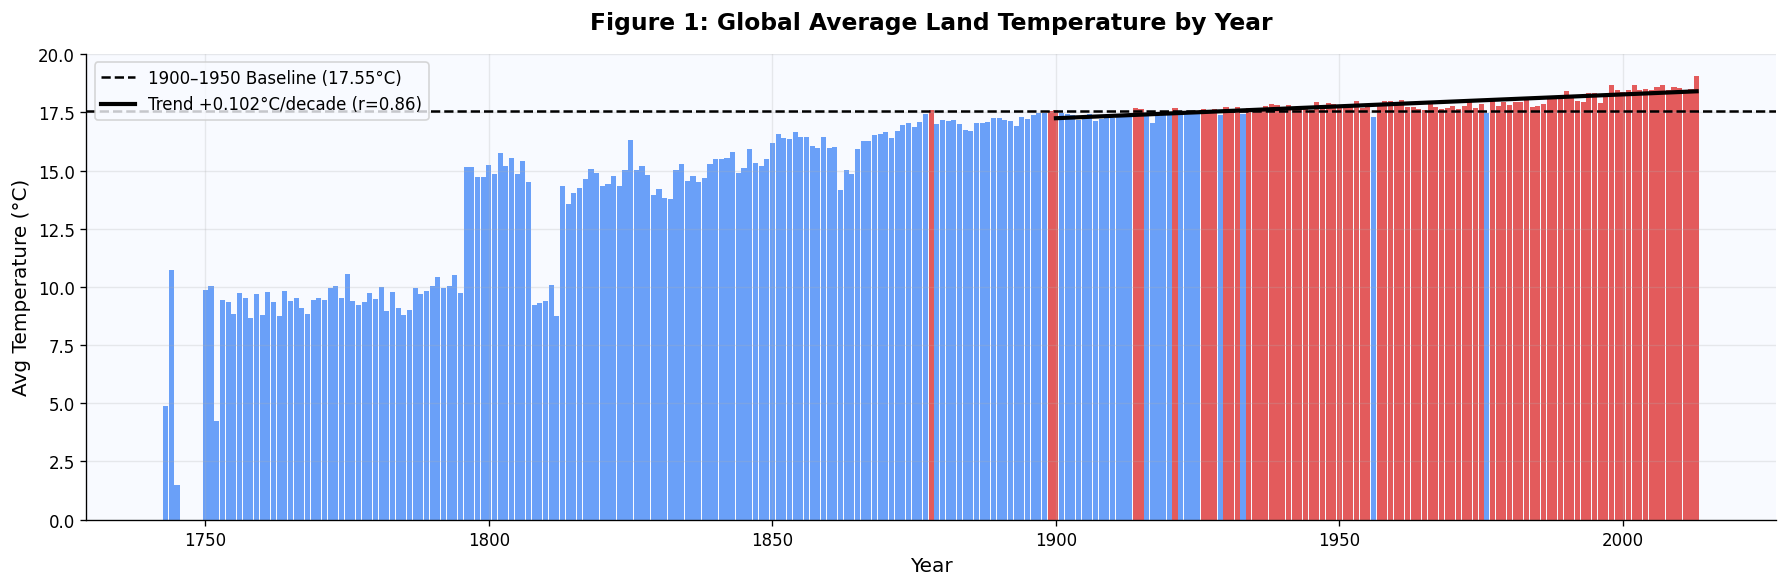

Fig 1 saved to Drive.


In [47]:
# ── Figure 1: Global Average Temperature Trend (yearly) ──────────────────────
global_yr = df_clean.groupby('Year')['Avg_Temp_C'].mean()

fig, ax = plt.subplots(figsize=(15, 5))

# Color bars warm/cool relative to 1900–1950 baseline
baseline = global_yr.loc[1900:1950].mean()
colors = ['#DC2626' if v > baseline else '#3B82F6' for v in global_yr.values]
ax.bar(global_yr.index, global_yr.values, color=colors, alpha=0.75, width=0.9)
ax.axhline(baseline, color='black', linewidth=1.5, linestyle='--',
           label=f'1900–1950 Baseline ({baseline:.2f}°C)')

# Trend line (post-1900 only)
post = global_yr[global_yr.index >= 1900]
slope, intercept, r, p, _ = stats.linregress(post.index, post.values)
x_line = np.array([post.index.min(), post.index.max()])
ax.plot(x_line, slope*x_line+intercept, 'k-', linewidth=2.5,
        label=f'Trend +{slope*10:.3f}°C/decade (r={r:.2f})', zorder=5)

ax.set_title('Figure 1: Global Average Land Temperature by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Temperature (°C)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig1_global_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved to Drive.')

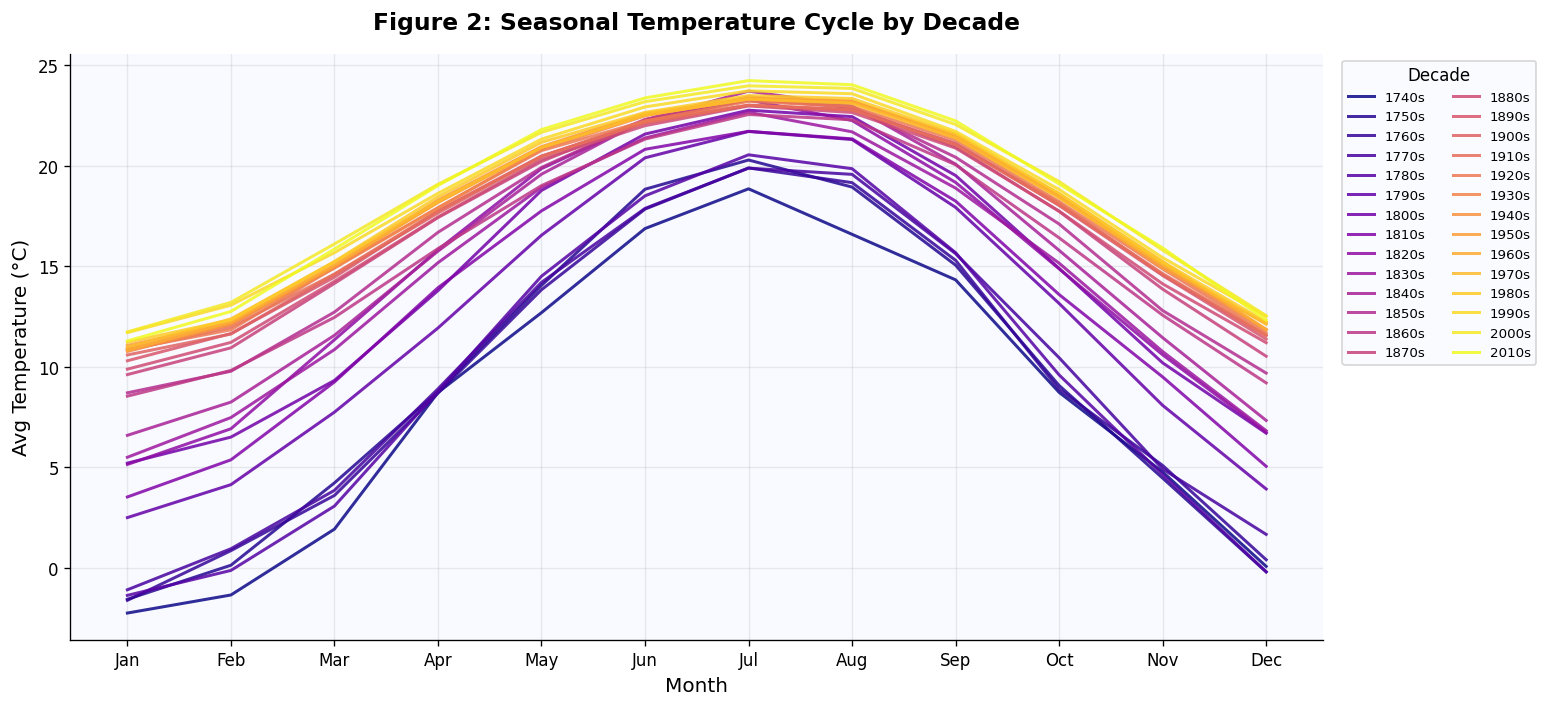

Fig 2 saved to Drive.


In [48]:
# ── Figure 2: Seasonal Cycle by Decade ───────────────────────────────────────
decades = sorted(df_clean['Decade'].unique())
cmap = plt.cm.get_cmap('plasma', len(decades))

fig, ax = plt.subplots(figsize=(13, 6))
for i, dec in enumerate(decades):
    sub = df_clean[df_clean['Decade']==dec].groupby('Month')['Avg_Temp_C'].mean()
    ax.plot(sub.index, sub.values, color=cmap(i/len(decades)),
            linewidth=1.8, alpha=0.85, label=f'{dec}s')

ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTH_NAMES, fontsize=10)
ax.set_title('Figure 2: Seasonal Temperature Cycle by Decade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg Temperature (°C)', fontsize=12)
ax.legend(title='Decade', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig2_seasonal_decades.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved to Drive.')

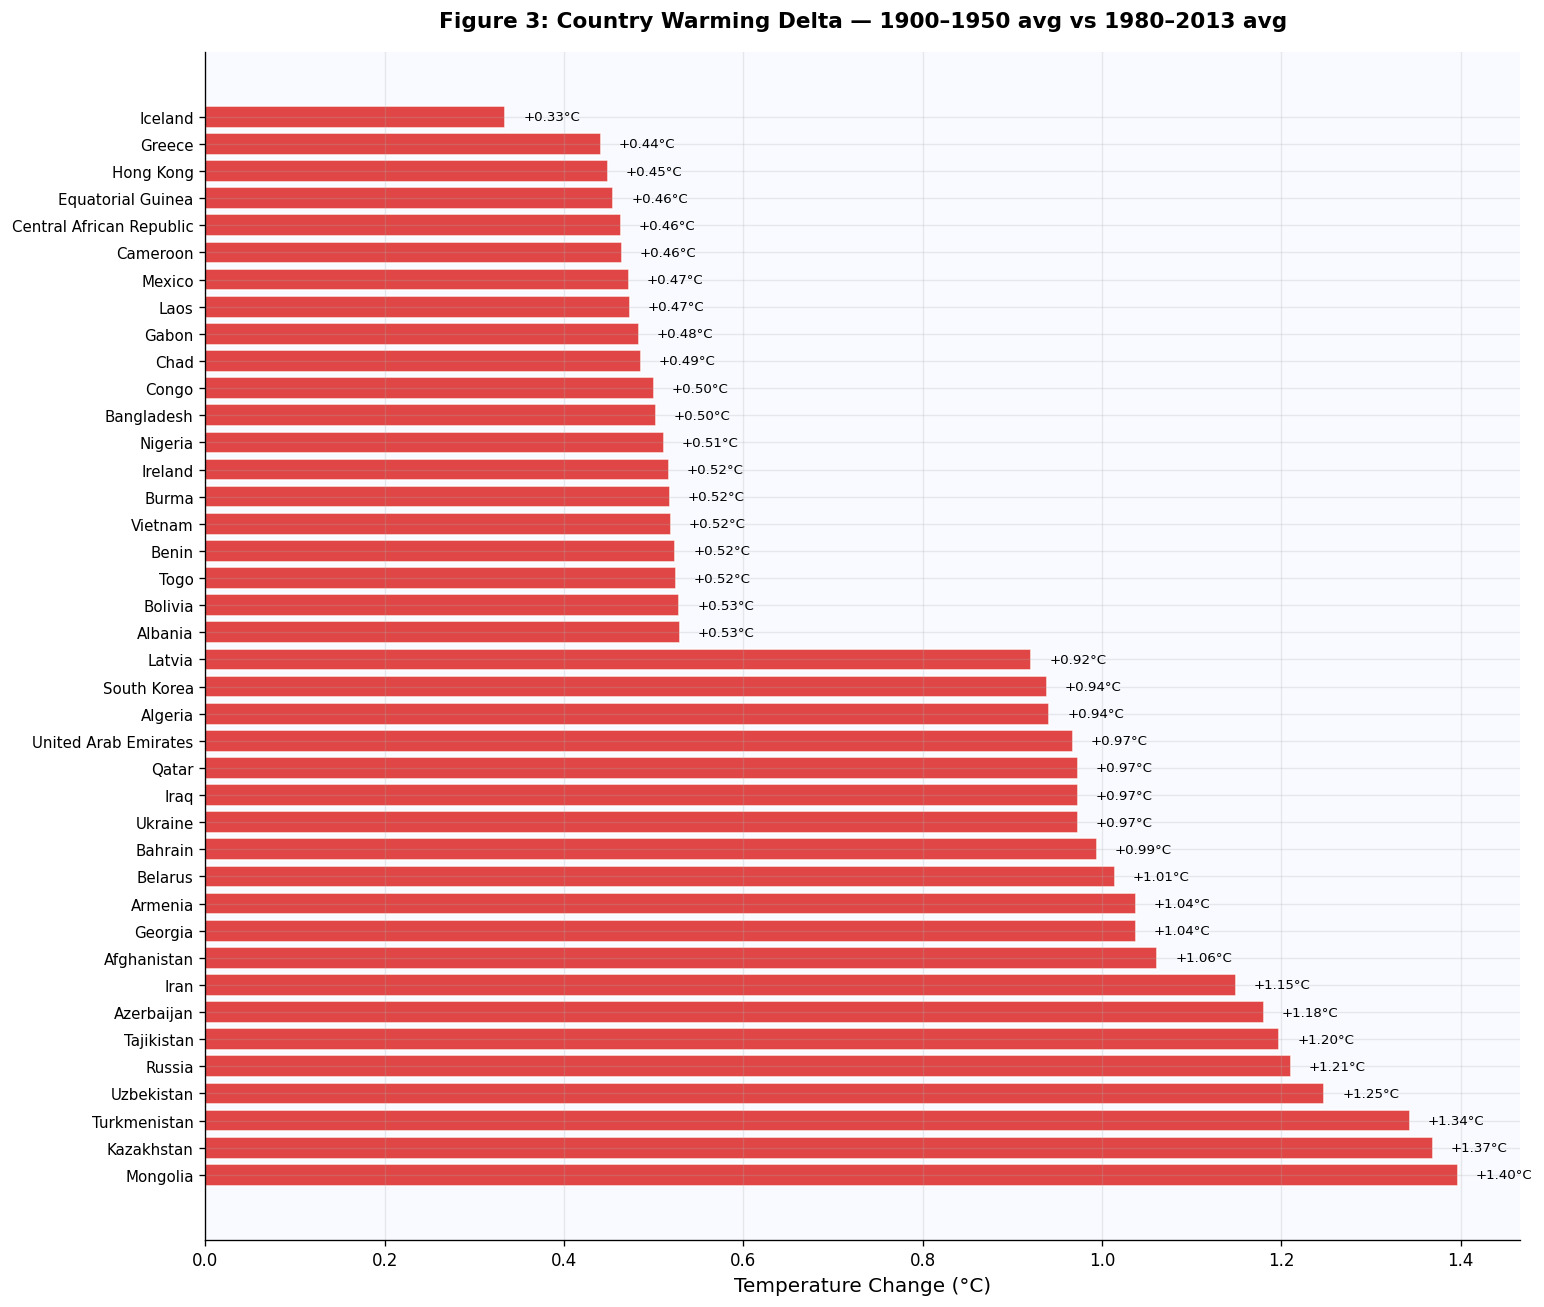

Fig 3 saved to Drive.


In [49]:
# ── Figure 3: Top & Bottom 20 Countries by Warming Delta ─────────────────────
top20  = delta.head(20)
bot20  = delta.tail(20)
combined = pd.concat([top20, bot20])

fig, ax = plt.subplots(figsize=(13, 11))
bar_colors = ['#DC2626' if v > 0 else '#3B82F6' for v in combined.values]
bars = ax.barh(combined.index, combined.values, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)

for bar, val in zip(bars, combined.values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f'+{val:.2f}°C' if val>=0 else f'{val:.2f}°C',
            va='center', ha='left' if val>=0 else 'right', fontsize=8)

ax.set_title('Figure 3: Country Warming Delta — 1900–1950 avg vs 1980–2013 avg', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Temperature Change (°C)', fontsize=12)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig3_country_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved to Drive.')

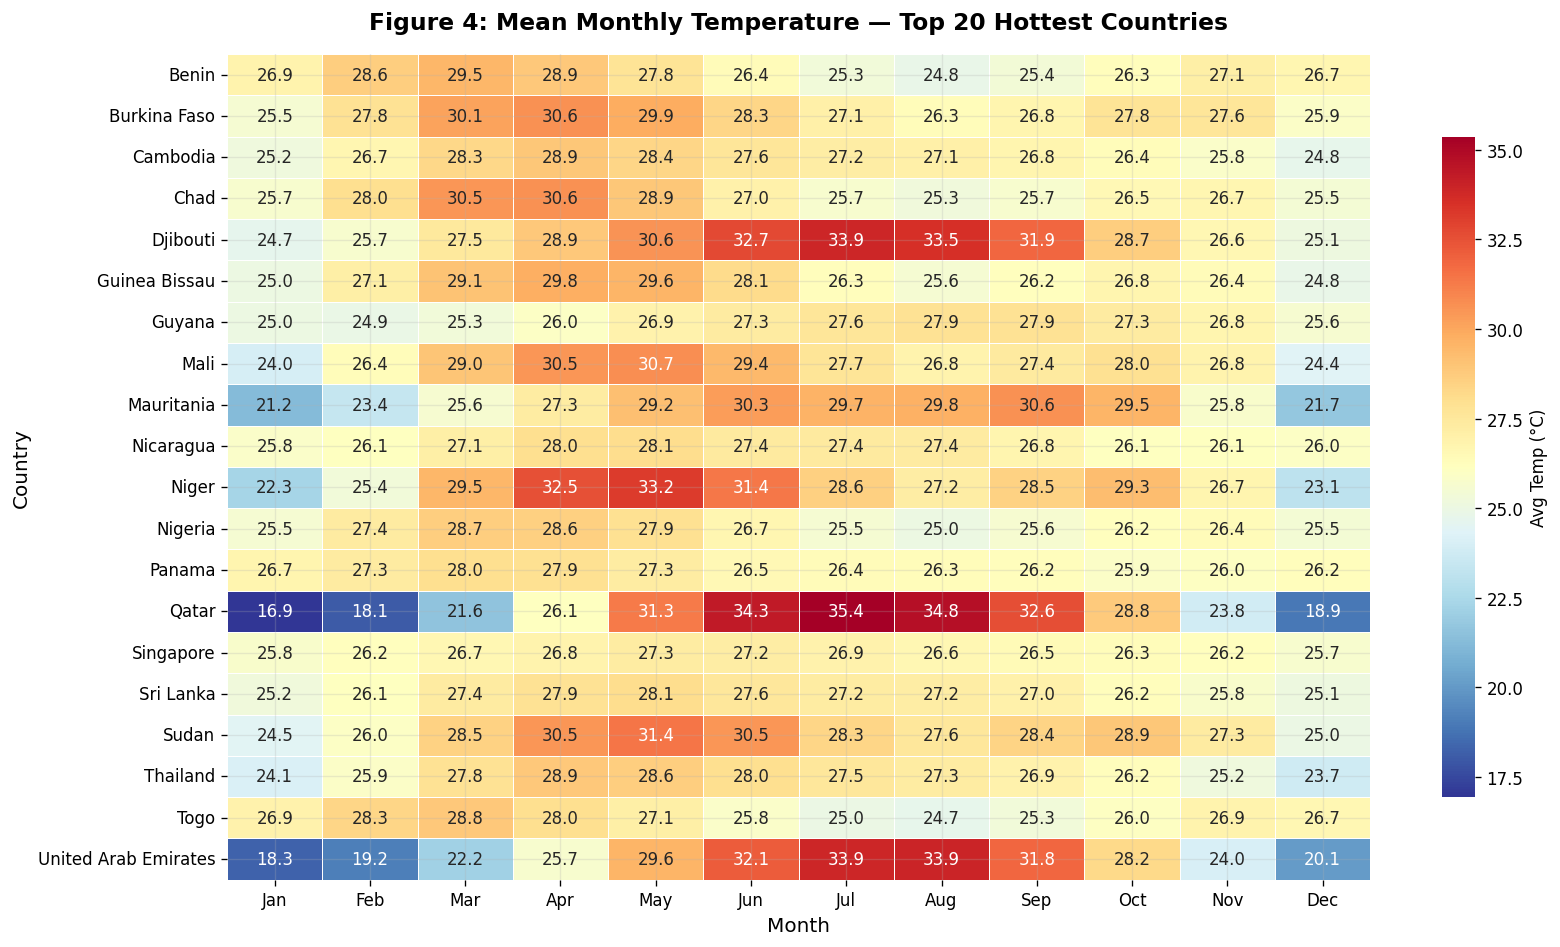

Fig 4 saved to Drive.


In [50]:
# ── Figure 4: Heatmap — Top 20 Countries × Month ─────────────────────────────
top20_countries = city_avg.groupby('Country').mean().sort_values(ascending=False).head(20).index
sub = df_clean[df_clean['Country'].isin(top20_countries)]
pivot = sub.pivot_table(index='Country', columns='Month', values='Avg_Temp_C', aggfunc='mean')
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Avg Temp (°C)', 'shrink': 0.8}, ax=ax)
ax.set_title('Figure 4: Mean Monthly Temperature — Top 20 Hottest Countries', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig4_country_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved to Drive.')

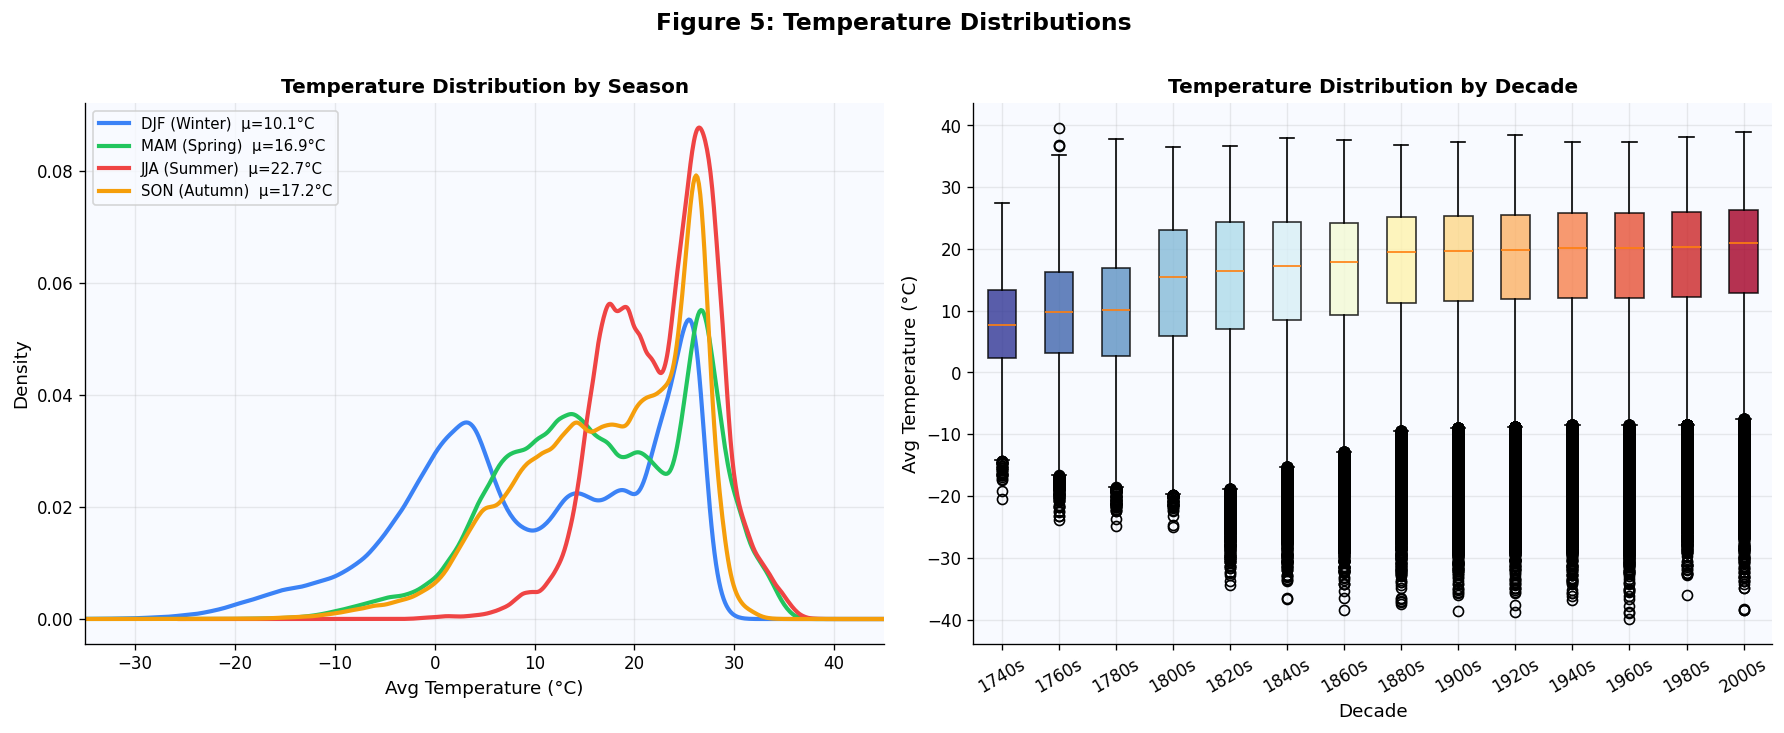

Fig 5 saved to Drive.


In [51]:
# ── Figure 5: Distribution of Temperatures by Season ─────────────────────────
SEASON_COLORS = {
    'DJF (Winter)':'#3B82F6', 'MAM (Spring)':'#22C55E',
    'JJA (Summer)':'#EF4444', 'SON (Autumn)':'#F59E0B'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KDE
ax = axes[0]
for season, color in SEASON_COLORS.items():
    sub = df_clean[df_clean['Season']==season]['Avg_Temp_C']
    sub.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{season}  μ={sub.mean():.1f}°C')
ax.set_title('Temperature Distribution by Season', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Temperature (°C)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-35, 45)

# Boxplot by decade (every 20 yrs to avoid clutter)
ax2 = axes[1]
decades_sparse = [d for d in decades if d % 20 == 0]
decade_data = [df_clean[df_clean['Decade']==d]['Avg_Temp_C'].values for d in decades_sparse]
cmap2 = plt.cm.get_cmap('RdYlBu_r', len(decades_sparse))
bp = ax2.boxplot(decade_data, labels=[f"{d}s" for d in decades_sparse], patch_artist=True)
for patch, i in zip(bp['boxes'], range(len(decades_sparse))):
    patch.set_facecolor(cmap2(i/len(decades_sparse)))
    patch.set_alpha(0.8)
ax2.set_title('Temperature Distribution by Decade', fontsize=12, fontweight='bold')
ax2.set_xlabel('Decade', fontsize=11)
ax2.set_ylabel('Avg Temperature (°C)', fontsize=11)
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Figure 5: Temperature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig5_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved to Drive.')

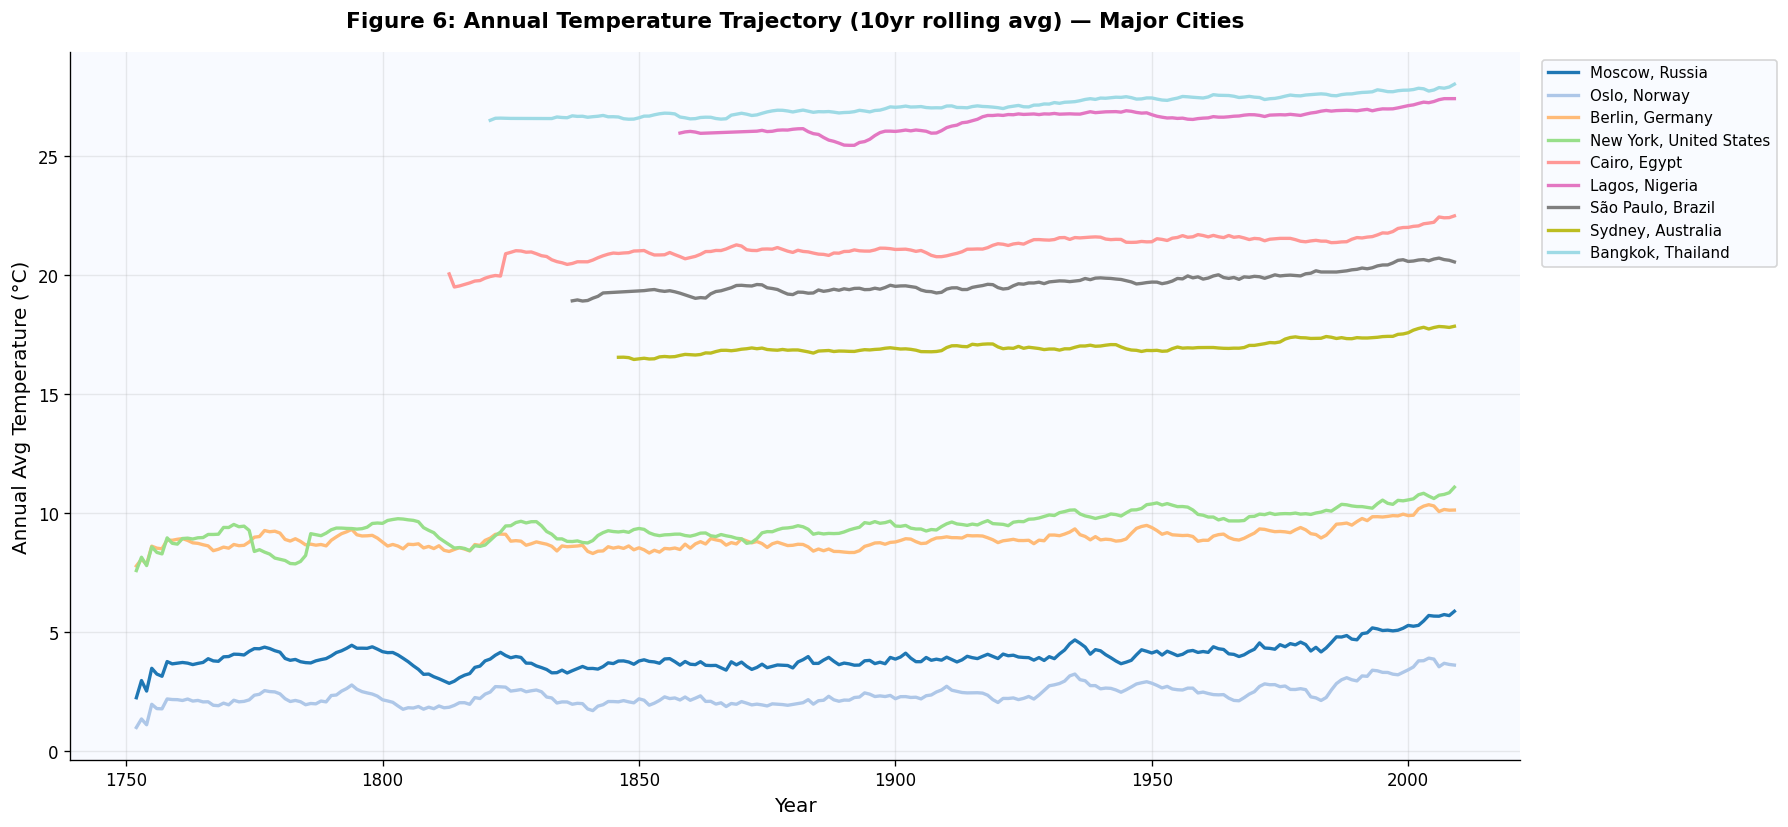

Fig 6 saved to Drive.


In [52]:
# ── Figure 6: Temperature Trajectories — 12 Major Cities ─────────────────────
track_cities = [
    ('Moscow', 'Russia'), ('Oslo', 'Norway'), ('Berlin', 'Germany'),
    ('New York', 'United States'), ('Cairo', 'Egypt'), ('Mumbai', 'India'),
    ('Beijing', 'China'), ('Lagos', 'Nigeria'), ('São Paulo', 'Brazil'),
    ('Sydney', 'Australia'), ('Buenos Aires', 'Argentina'), ('Bangkok', 'Thailand')
]

cmap3 = plt.cm.get_cmap('tab20', len(track_cities))
fig, ax = plt.subplots(figsize=(15, 7))

for i, (city, country) in enumerate(track_cities):
    sub = df_clean[
        (df_clean['City'].astype(str) == city) &
        (df_clean['Country'].astype(str) == country)
    ].groupby('Year')['Avg_Temp_C'].mean()
    if len(sub) > 10:
        smoothed = sub.rolling(10, center=True).mean()
        ax.plot(smoothed.index, smoothed.values, color=cmap3(i/len(track_cities)),
                linewidth=2, label=f'{city}, {country}')

ax.set_title('Figure 6: Annual Temperature Trajectory (10yr rolling avg) — Major Cities', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Avg Temperature (°C)', fontsize=12)
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig6_city_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved to Drive.')

## 6. Row Count Verification & Export <a id='6'></a>

In [53]:
TARGET = 500_000
raw_rows   = len(df_raw)
clean_rows = len(df_clean)

print('=' * 55)
print(f'  Raw rows (before cleaning):   {raw_rows:>10,}')
print(f'  Clean rows (after null drop): {clean_rows:>10,}')
print(f'  Target minimum:               {TARGET:>10,}')
print(f'  Requirement met:              {"✅ YES" if clean_rows >= TARGET else "❌ NO"}')
print('=' * 55)
print(f'\nDataset is {clean_rows/TARGET:.1f}x the minimum requirement.')

  Raw rows (before cleaning):    8,599,212
  Clean rows (after null drop):  8,235,082
  Target minimum:                  500,000
  Requirement met:              ✅ YES

Dataset is 16.5x the minimum requirement.


In [55]:
# ── Export cleaned dataset to Drive ──────────────────────────────────────────
EXPORT_PATH = '/content/drive/MyDrive/GlobalLandTemp_cleaned.csv'

export_cols = ['dt','Year','Month','Month_Name','Season','Decade',
               'City','Country','Latitude','Longitude',
               'Avg_Temp_C','Temp_Uncertainty_C']

df_clean[export_cols].to_csv(EXPORT_PATH, index=False)

print(f'✅ Cleaned dataset exported to Drive:')
print(f'   Path:  {EXPORT_PATH}')
print(f'   Shape: {df_clean[export_cols].shape[0]:,} rows × {len(export_cols)} columns')
print(f'\nNew columns added:')
print(f'   Year       — integer year extracted from dt')
print(f'   Month      — integer month (1–12)')
print(f'   Month_Name — abbreviated label (Jan, Feb, ...)')
print(f'   Season     — DJF / MAM / JJA / SON')
print(f'   Decade     — decade start year (e.g. 1900, 1910, ...)')

✅ Cleaned dataset exported to Drive:
   Path:  /content/drive/MyDrive/GlobalLandTemp_cleaned.csv
   Shape: 8,235,082 rows × 12 columns

New columns added:
   Year       — integer year extracted from dt
   Month      — integer month (1–12)
   Month_Name — abbreviated label (Jan, Feb, ...)
   Season     — DJF / MAM / JJA / SON
   Decade     — decade start year (e.g. 1900, 1910, ...)
